Dimensión de la matriz de SPEI-6 (Estaciones x Meses): (18, 288)
Advertencia: Se detectaron 90 valores perdidos en SPEI-6. Imputando por interpolación...
Coeficiente de Silueta para k=2 grupos: 0.1758
Coeficiente de Silueta para k=3 grupos: 0.1682
Coeficiente de Silueta para k=4 grupos: 0.1548
Coeficiente de Silueta para k=5 grupos: 0.1592

Número óptimo de clústeres seleccionado (k*): 2

--- Validación de Contigüidad Espacial ---
Distancia geográfica promedio INTRA-CLÚSTER (mismo grupo): 2.438° decimales
Distancia geográfica promedio INTER-CLÚSTER (grupos distintos): 3.322° decimales
Conclusión espacial: Si la distancia intra-clúster es sustancialmente menor que la inter-clúster,
las subregiones de sequía son geográficamente compactas y físicamente coherentes.


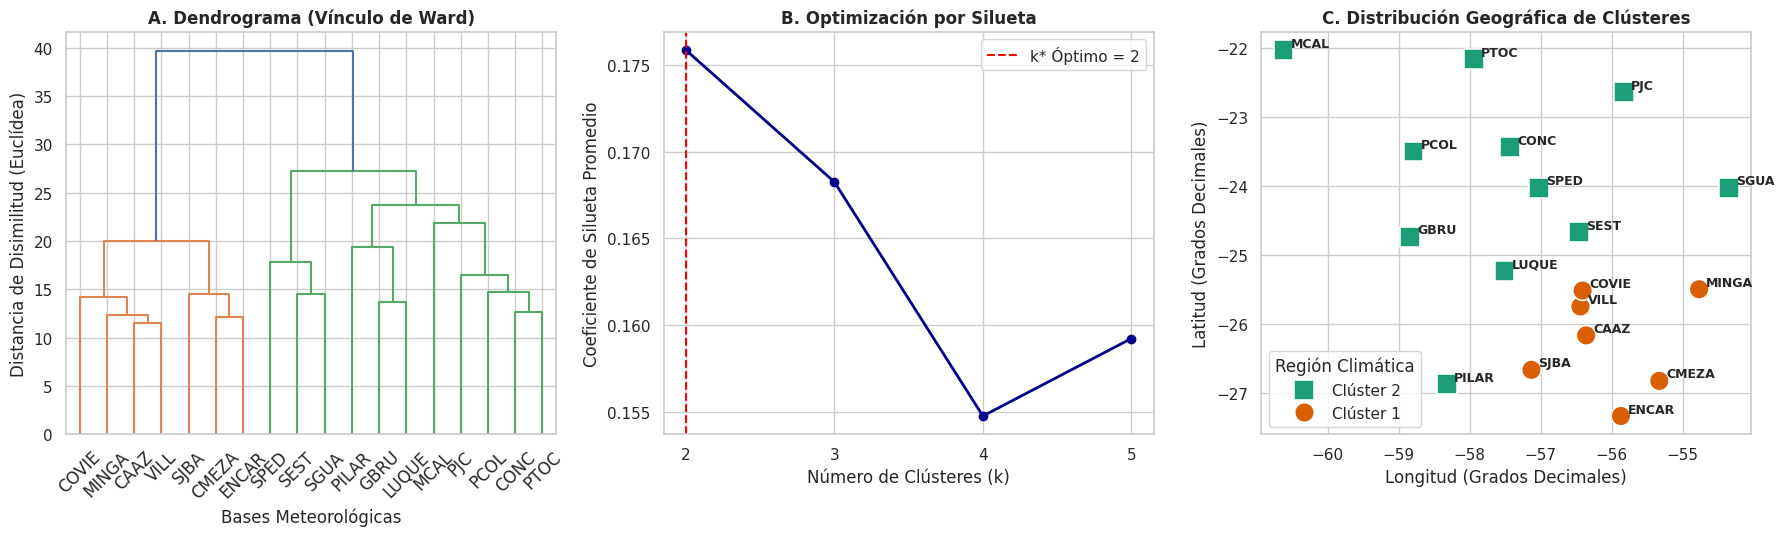


Asignación definitiva de bases por clúster:
   estacion_id  cluster  latitud  longitud
12       MINGA        1   -25.50    -54.77
14        SJBA        1   -26.67    -57.13
10        VILL        1   -25.75    -56.44
15        CAAZ        1   -26.17    -56.36
11       COVIE        1   -25.52    -56.41
16       CMEZA        1   -26.83    -55.33
17       ENCAR        1   -27.34    -55.87
0         MCAL        2   -22.03    -60.62
7         SEST        2   -24.67    -56.46
6         SPED        2   -24.03    -57.02
5         GBRU        2   -24.74    -58.84
4         CONC        2   -23.44    -57.43
3         PCOL        2   -23.50    -58.79
9        LUQUE        2   -25.24    -57.51
2          PJC        2   -22.64    -55.83
1         PTOC        2   -22.16    -57.94
13       PILAR        2   -26.88    -58.32
8         SGUA        2   -24.03    -54.35


In [2]:
# PROYECTO DE TESIS: DINÁMICAS DE LA SEQUÍA EN PARAGUAY (2000-2023)
# Algoritmo de Regionalización mediante Clustering Jerárquico Aglomerativo (Ward)

# 1. Importación de librerías científicas y de visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuración estética de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.titlesize': 14})

# 2. Carga y Preparación de los Datos

# Cargar metadatos (coordenadas) y datos mensuales de SPEI
df_meta = pd.read_csv('../../data/processed/metadata_estaciones_finales.csv')
df_datos = pd.read_csv('../../data/processed/datos_mensuales_con_spei.csv')

# Filtrar columnas relevantes y pivotar la matriz: Estaciones en filas, Fechas en columnas
# De esta manera, cada fila representa la serie temporal continua de SPEI-6 de una estación
df_pivot = df_datos.pivot(index='estacion_id', columns='fecha', values='spei_6')

# Control de calidad de la matriz pivotada
print(f"Dimensión de la matriz de SPEI-6 (Estaciones x Meses): {df_pivot.shape}")
missing_count = df_pivot.isnull().sum().sum()
if missing_count > 0:
    print(f"Advertencia: Se detectaron {missing_count} valores perdidos en SPEI-6. Imputando por interpolación...")
    df_pivot = df_pivot.interpolate(method='linear', axis=1).bfill(axis=1)
else:
    print("Base de datos de SPEI-6 completa y verificada (0% faltantes).")


# 3. Modelado Jerárquico Aglomerativo (Método de Ward)
# ==============================================================================
# Calcular la matriz de enlace jerárquico utilizando distancia euclídea y enlace de Ward
Z = linkage(df_pivot, method='ward', metric='euclidean')


# 4. Optimización del Número de Clústeres (Coeficiente de Silueta)
# ==============================================================================
K_range = range(2, 6)  # Evaluamos particiones de 2 a 5 grupos
sil_scores = []

for k in K_range:
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(df_pivot, labels, metric='euclidean')
    sil_scores.append(score)
    print(f"Coeficiente de Silueta para k={k} grupos: {score:.4f}")

# Determinar el k óptimo
k_optimo = K_range[np.argmax(sil_scores)]
print(f"\nNúmero óptimo de clústeres seleccionado (k*): {k_optimo}")

# Asignar etiquetas óptimas a las estaciones
labels_optimos = fcluster(Z, k_optimo, criterion='maxclust')
df_cluster = pd.DataFrame({
    'estacion_id': df_pivot.index,
    'cluster': labels_optimos
})

# Fusionar asignación con las coordenadas geográficas
df_mapa = pd.merge(df_meta, df_cluster, on='estacion_id')


# 5. Validación de la Contigüidad Geográfica de los Clústeres

# Para demostrar que la agrupación temporal tiene coherencia espacial, calculamos
# la distancia geográfica promedio (en grados decimales) intra-clúster vs inter-clúster.
coord_cols = ['latitud', 'longitud']
dist_geo_matrix = squareform(pdist(df_mapa[coord_cols], metric='euclidean'))
df_dist_geo = pd.DataFrame(dist_geo_matrix, index=df_mapa['estacion_id'], columns=df_mapa['estacion_id'])

intra_dist = []
inter_dist = []

for i in range(len(df_mapa)):
    est_i = df_mapa.iloc[i]['estacion_id']
    clu_i = df_mapa.iloc[i]['cluster']
    for j in range(i+1, len(df_mapa)):
        est_j = df_mapa.iloc[j]['estacion_id']
        clu_j = df_mapa.iloc[j]['cluster']
        dist_ij = df_dist_geo.loc[est_i, est_j]
        
        if clu_i == clu_j:
            intra_dist.append(dist_ij)
        else:
            inter_dist.append(dist_ij)

print("\n--- Validación de Contigüidad Espacial ---")
print(f"Distancia geográfica promedio INTRA-CLÚSTER (mismo grupo): {np.mean(intra_dist):.3f}° decimales")
print(f"Distancia geográfica promedio INTER-CLÚSTER (grupos distintos): {np.mean(inter_dist):.3f}° decimales")
print("Conclusión espacial: Si la distancia intra-clúster es sustancialmente menor que la inter-clúster,")
print("las subregiones de sequía son geográficamente compactas y físicamente coherentes.")


# 6. Generación de Gráficos (CORREGIDO PARA EVITAR INVERSIÓN EN LA LEYENDA)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Gráfico A: Dendrograma de Ward
dendrogram(Z, labels=df_pivot.index, ax=axes[0], leaf_rotation=45)
axes[0].set_title("A. Dendrograma (Vínculo de Ward)", fontweight='bold')
axes[0].set_xlabel("Bases Meteorológicas")
axes[0].set_ylabel("Distancia de Disimilitud (Euclídea)")

# Gráfico B: Coeficiente de Silueta para Selección de K
axes[1].plot(K_range, sil_scores, marker='o', color='darkblue', linewidth=2)
axes[1].axvline(k_optimo, color='red', linestyle='--', label=f'k* Óptimo = {k_optimo}')
axes[1].set_title("B. Optimización por Silueta", fontweight='bold')
axes[1].set_xlabel("Número de Clústeres (k)")
axes[1].set_ylabel("Coeficiente de Silueta Promedio")
axes[1].set_xticks(K_range)
axes[1].legend()

# Gráfico C: Distribución Espacial y Contigüidad ajustado para 2 clústeres
#colors_optimos = {1: '#d95f02', 2: '#1b9e77'} # Paleta adaptada para 2 grupos
# Mapeamos los IDs numéricos a nombres descriptivos directamente en el DataFrame
df_mapa['cluster_name'] = df_mapa['cluster'].map({1: 'Clúster 1', 2: 'Clúster 2'})

# Definimos diccionarios explícitos para mapear colores y marcadores a cada nombre
colors_dict = {'Clúster 1': '#d95f02', 'Clúster 2': '#1b9e77'} # Clúster 1: Naranja, Clúster 2: Verde
markers_dict = {'Clúster 1': 'o', 'Clúster 2': 's'}            # Clúster 1: Círculo, Clúster 2: Cuadrado

# Graficamos usando 'cluster_name' como parámetro de hue y style
sns.scatterplot(
    data=df_mapa, x='longitud', y='latitud', 
    hue='cluster_name', style='cluster_name',
    palette=colors_dict, markers=markers_dict, s=200, ax=axes[2]
)

# Anotaciones de nombres de estaciones
for idx, row in df_mapa.iterrows():
    axes[2].text(row['longitud'] + 0.1, row['latitud'] + 0.05, row['estacion_id'], fontsize=9, fontweight='bold')

axes[2].set_title("C. Distribución Geográfica de Clústeres", fontweight='bold')
axes[2].set_xlabel("Longitud (Grados Decimales)")
axes[2].set_ylabel("Latitud (Grados Decimales)")

# La leyenda se genera de forma automática y correcta sin necesidad de reescribir las etiquetas manualmente
axes[2].legend(title="Región Climática")

plt.tight_layout()
plt.savefig('analisis_regionalizacion_sequia.png', dpi=300)
plt.show()

# Mostrar asignación detallada final
print("\nAsignación definitiva de bases por clúster:")
print(df_mapa[['estacion_id', 'cluster', 'latitud', 'longitud']].sort_values(by='cluster'))